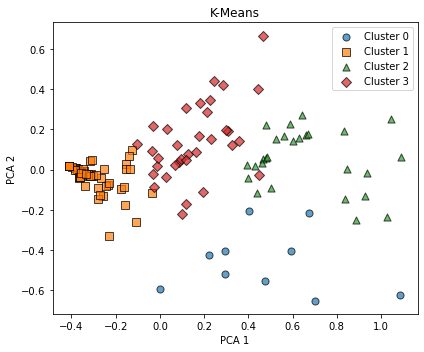

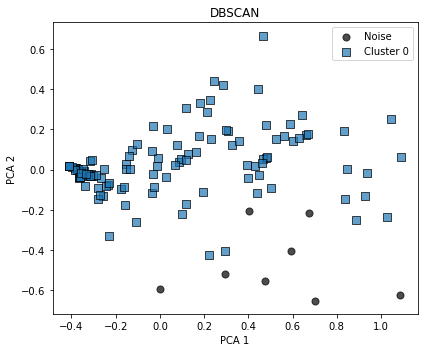

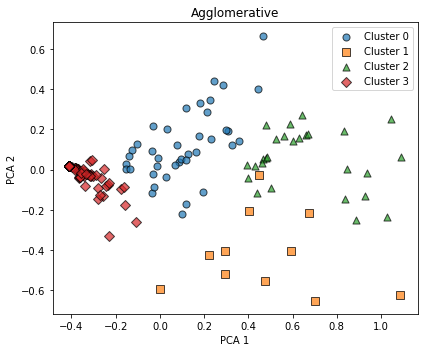

K-Means silhouette score: 0.534
DBSCAN silhouette score: 0.436
Agglomerative silhouette score: 0.519


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score


# Detect the repository root
current_dir = Path.cwd()

if (current_dir / "data").exists():
    repository_root = current_dir
elif (current_dir.parent / "data").exists():
    repository_root = current_dir.parent
else:
    raise FileNotFoundError(
        "The repository data directory could not be found. "
        "Run the notebook from the repository root or from the notebooks directory."
    )


# Dataset path
data_path = repository_root / "data" / "Dataset_Consumo_Label_v1.xlsx"

if not data_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Place 'Dataset_Consumo_Label_v1.xlsx' "
        "inside the repository data directory."
    )


# Load the dataset
df = pd.read_excel(data_path)


# Verify the required columns
hour_columns = [f"H{i}" for i in range(1, 25)]

required_columns = [
    "Fecha",
    "Consumo",
    *hour_columns
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "The dataset is missing the following required columns: "
        f"{missing_columns}"
    )


# Convert the date column
df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    errors="coerce"
)

df = df.dropna(subset=["Fecha"]).copy()


# Select the analysis period
start_date = pd.Timestamp("2024-11-23")
end_date = pd.Timestamp("2025-04-26")

df = df[
    (df["Fecha"] >= start_date) &
    (df["Fecha"] <= end_date)
].copy()

if df.empty:
    raise ValueError(
        "No observations were found within the selected date range."
    )


# Calculate water consumption by operational shift
df["MorningShift"] = df[
    [
        "H7", "H8", "H9", "H10", "H11",
        "H12", "H13", "H14", "H15"
    ]
].sum(axis=1)

df["AfternoonShift"] = df[
    [
        "H16", "H17", "H18", "H19",
        "H20", "H21", "H22", "H23"
    ]
].sum(axis=1)

df["NightShift"] = df[
    [
        "H24", "H1", "H2", "H3",
        "H4", "H5", "H6"
    ]
].sum(axis=1)


# Select the clustering features
features = [
    "Consumo",
    "MorningShift",
    "AfternoonShift",
    "NightShift"
]

df = df.dropna(subset=features).copy()

if len(df) < 4:
    raise ValueError(
        "At least four valid observations are required "
        "for the clustering analysis."
    )


# Normalize the input features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[features])


# Reduce the normalized data to two principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


# Apply the unsupervised-learning algorithms
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)


dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(X_scaled)


agglomerative = AgglomerativeClustering(
    n_clusters=4
)

labels_agglomerative = agglomerative.fit_predict(X_scaled)


# Marker sequence used to distinguish clusters
markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "*",
    "x",
    "P"
]


# Plot the K-Means clustering result
fig, ax = plt.subplots(figsize=(6, 5))

for index, label in enumerate(np.unique(labels_kmeans)):
    mask = labels_kmeans == label

    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=markers[index % len(markers)],
        label=f"Cluster {label}",
        edgecolor="black",
        s=50,
        alpha=0.7
    )

ax.set_title("K-Means")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend()

fig.tight_layout()
plt.show()


# Plot the DBSCAN clustering result
fig, ax = plt.subplots(figsize=(6, 5))

for index, label in enumerate(np.unique(labels_dbscan)):
    mask = labels_dbscan == label

    point_color = "black" if label == -1 else f"C{label}"
    point_label = "Noise" if label == -1 else f"Cluster {label}"

    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=markers[index % len(markers)],
        label=point_label,
        edgecolor="black",
        color=point_color,
        s=50,
        alpha=0.7
    )

ax.set_title("DBSCAN")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend()

fig.tight_layout()
plt.show()


# Plot the agglomerative-clustering result
fig, ax = plt.subplots(figsize=(6, 5))

for index, label in enumerate(np.unique(labels_agglomerative)):
    mask = labels_agglomerative == label

    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=markers[index % len(markers)],
        label=f"Cluster {label}",
        edgecolor="black",
        s=50,
        alpha=0.7
    )

ax.set_title("Agglomerative")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend()

fig.tight_layout()
plt.show()


# Calculate the silhouette score for each clustering method
clustering_results = {
    "K-Means": labels_kmeans,
    "DBSCAN": labels_dbscan,
    "Agglomerative": labels_agglomerative
}

for method, labels in clustering_results.items():
    number_of_clusters = len(np.unique(labels))

    if number_of_clusters > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"{method} silhouette score: {score:.3f}")
    else:
        print(
            f"{method} did not produce enough clusters "
            "to calculate the silhouette score."
        )